In [1]:
!pip install -q pydicom opencv-python-headless ultralytics pandas numpy matplotlib scikit-learn


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 36.1 MB/s eta 0:00:00


In [2]:
import os
import glob
import pydicom
from pydicom.pixel_data_handlers.util import apply_voi_lut
import cv2
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
import torch
import shutil
import random

# What is CUDA? 
# CUDA is a computing platform by NVIDIA that allows PyTorch to use the GPU for parallel processing.
# Using a GPU makes model training take minutes instead of days.
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
if torch.cuda.is_available():
    print(f"GPU Name: {torch.cuda.get_device_name(0)}")
else:
    print("WARNING: No GPU found. Please turn on 'GPU T4 x2' or 'P100' in Kaggle settings.")


Using device: cuda
GPU Name: Tesla T4


In [3]:
# Kaggle datasets can be nested inside /kaggle/input/ or /kaggle/input/competitions/.
# This script recursively searches for the exact directory containing the 'train.csv' file.
BASE_DIR = None
for root, dirs, files in os.walk('/kaggle/input'):
    if 'train.csv' in files:
        BASE_DIR = root
        break

if BASE_DIR is None:
    raise FileNotFoundError("VinBigData dataset (train.csv) not found! Make sure you added the dataset to your notebook.")

TRAIN_DIR = os.path.join(BASE_DIR, 'train')
CSV_PATH = os.path.join(BASE_DIR, 'train.csv')

print(f"Selected BASE_DIR: {BASE_DIR}")
train_dicoms = sorted(glob.glob(os.path.join(TRAIN_DIR, '*.dicom')))
print(f"Train DICOM files found: {len(train_dicoms):,}")

OUTPUT_DIR = '/kaggle/working/cliniscan'
IMG_TRAIN = os.path.join(OUTPUT_DIR, 'dataset/images/train')
LBL_TRAIN = os.path.join(OUTPUT_DIR, 'dataset/labels/train')
IMG_VAL   = os.path.join(OUTPUT_DIR, 'dataset/images/val')
LBL_VAL   = os.path.join(OUTPUT_DIR, 'dataset/labels/val')

for d in [IMG_TRAIN, IMG_VAL, LBL_TRAIN, LBL_VAL]:
    os.makedirs(d, exist_ok=True)


Selected BASE_DIR: /kaggle/input/competitions/vinbigdata-chest-xray-abnormalities-detection
Train DICOM files found: 15,000


In [4]:
df = pd.read_csv(CSV_PATH)
df.fillna(0, inplace=True) 

class_dict = {
    0: 'Aortic enlargement', 1: 'Atelectasis', 2: 'Calcification', 3: 'Cardiomegaly',
    4: 'Consolidation', 5: 'ILD', 6: 'Infiltration', 7: 'Lung Opacity',
    8: 'Nodule/Mass', 9: 'Other lesion', 10: 'Pleural effusion', 11: 'Pleural thickening',
    12: 'Pneumothorax', 13: 'Pulmonary fibrosis', 14: 'No finding'
}

# Generate consistent random colors for each class for visualization
np.random.seed(42)
class_colors = {i: [int(c) for c in np.random.randint(0, 255, size=3)] for i in range(15)}

# Use ALL 15,000 unique images to satisfy Milestone 1 "significant portion"
unique_images = df['image_id'].unique()
np.random.seed(42)
subset_images = unique_images  

# 80/20 train/val split for the 15,000 images
split_index = int(0.8 * len(subset_images))
train_samples = set(subset_images[:split_index])
val_samples = set(subset_images[split_index:])

df_subset = df[df['image_id'].isin(subset_images)]
IMG_SIZE = 512

def process_dicom_to_png_and_yolo(img_id, split_name):
    dicom_path = os.path.join(TRAIN_DIR, f"{img_id}.dicom")
    if not os.path.exists(dicom_path): return False
        
    # pydicom.dcmread is the modern replacement for pydicom.read_file
    dicom = pydicom.dcmread(dicom_path)
    data = apply_voi_lut(dicom.pixel_array, dicom)
    if dicom.PhotometricInterpretation == 'MONOCHROME1':
        data = np.amax(data) - data
    data = data - np.min(data)
    data = data / np.max(data)
    data = (data * 255).astype(np.uint8)
    
    original_h, original_w = data.shape
    resized_img = cv2.resize(data, (IMG_SIZE, IMG_SIZE))
    
    img_folder = IMG_TRAIN if split_name == 'train' else IMG_VAL
    cv2.imwrite(os.path.join(img_folder, f"{img_id}.png"), resized_img)
    
    label_folder = LBL_TRAIN if split_name == 'train' else LBL_VAL
    img_annotations = df[df['image_id'] == img_id]
    
    yolo_lines = []
    for _, row in img_annotations.iterrows():
        class_id = int(row['class_id'])
        if class_id == 14: continue # Skip "No finding" for detection boxes
            
        x_min, y_min = row['x_min'] / original_w, row['y_min'] / original_h
        x_max, y_max = row['x_max'] / original_w, row['y_max'] / original_h
        
        x_center, y_center = (x_min + x_max) / 2, (y_min + y_max) / 2
        width, height = x_max - x_min, y_max - y_min
        yolo_lines.append(f"{class_id} {x_center:.6f} {y_center:.6f} {width:.6f} {height:.6f}")
        
    with open(os.path.join(label_folder, f"{img_id}.txt"), "w") as f:
        f.write("\n".join(yolo_lines))
    return True

print(f"Converting all {len(subset_images)} DICOMs to PNG and generating YOLO labels...")
print("WARNING: This full conversion will take approx. 2.5 hours on Kaggle.")
for img_id in tqdm(subset_images):
    split = 'train' if img_id in train_samples else 'val'
    process_dicom_to_png_and_yolo(img_id, split)


Converting all 15000 DICOMs to PNG and generating YOLO labels...


100%|██████████| 15000/15000 [4:42:11<00:00,  1.13s/it]


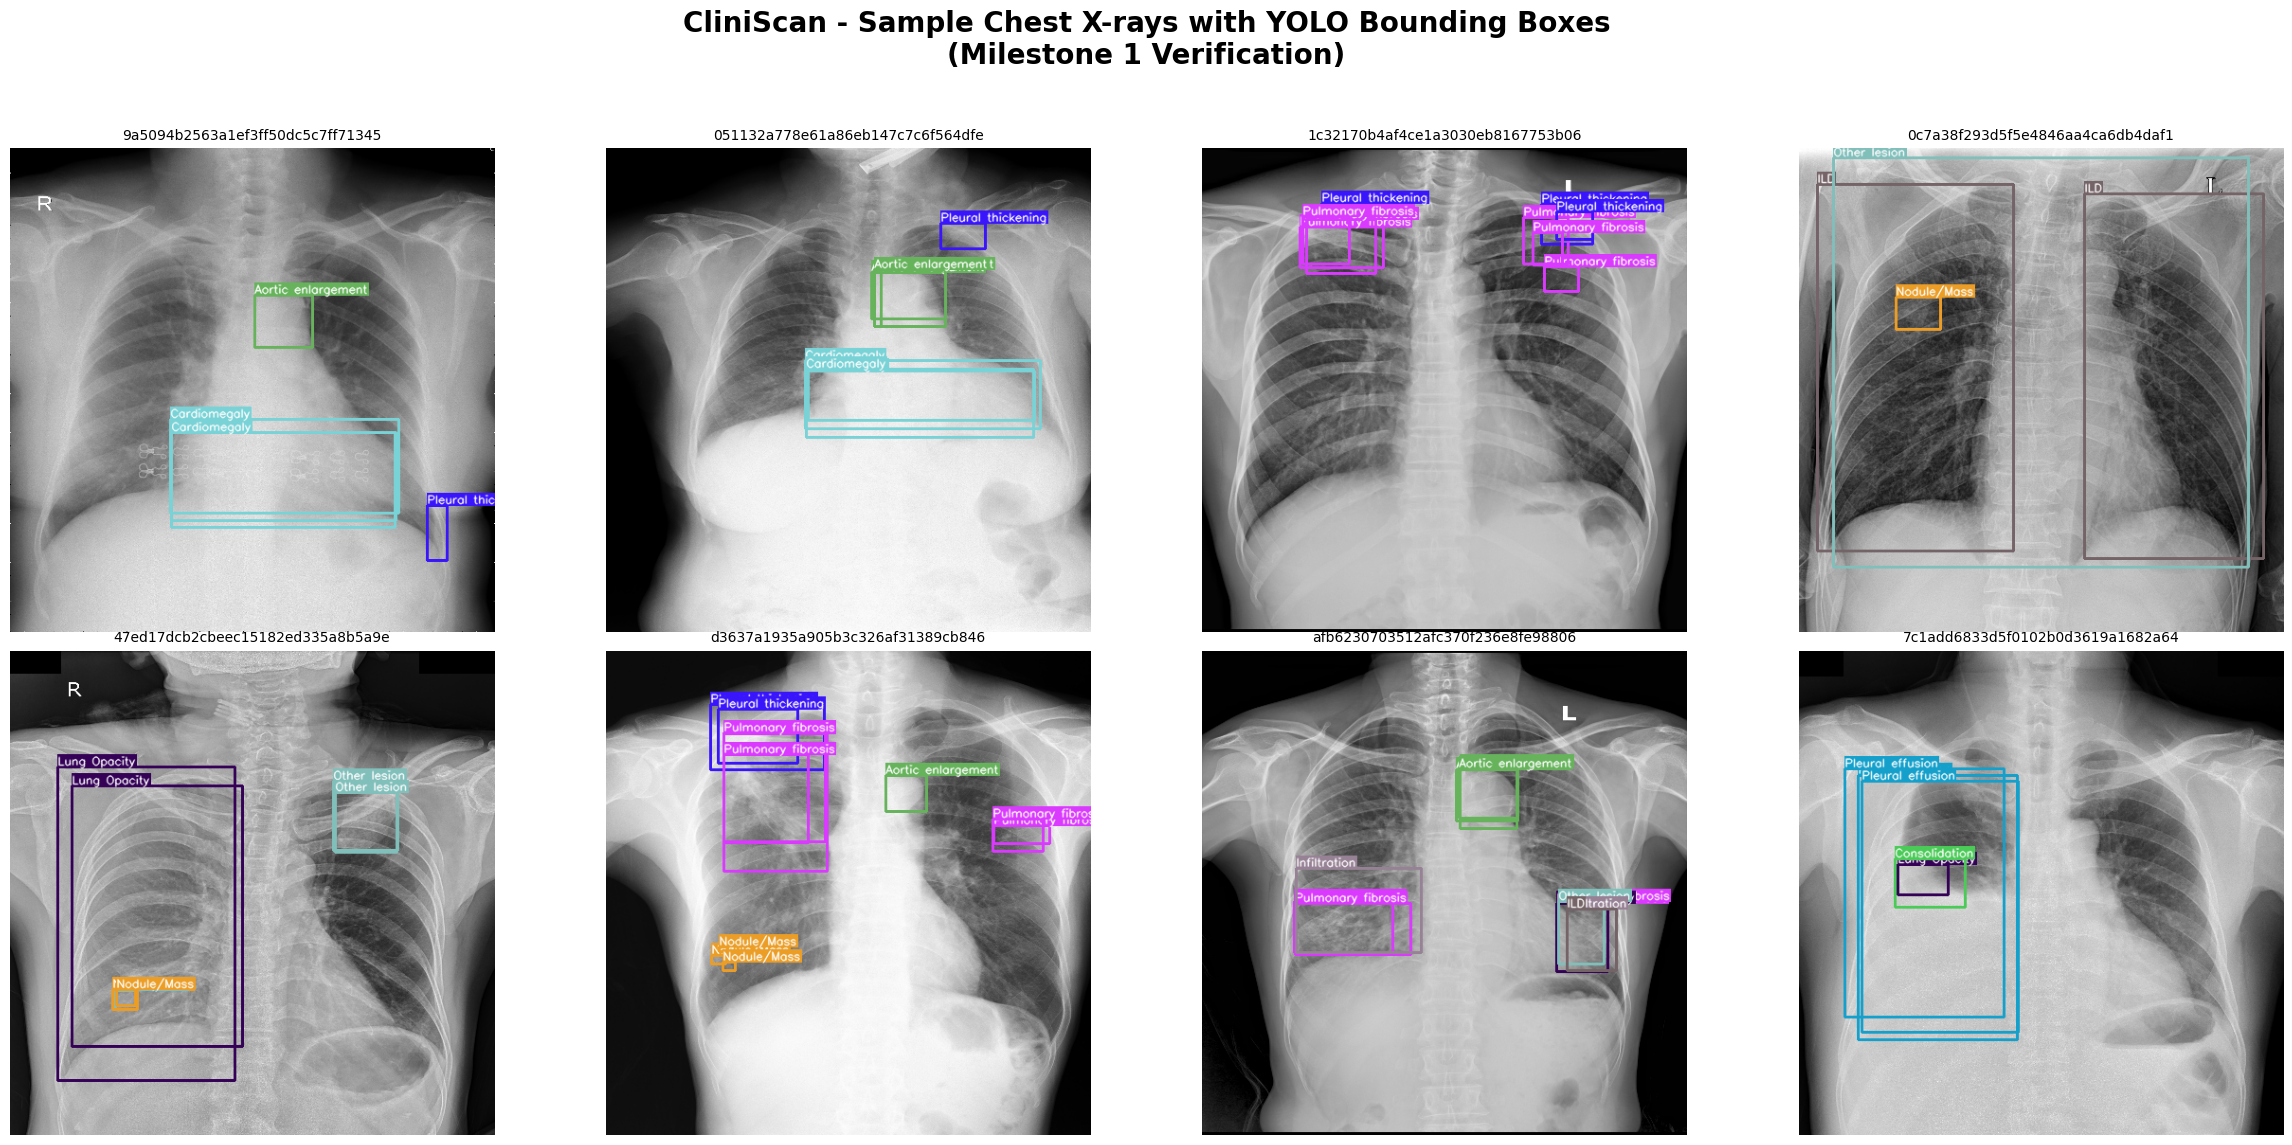

In [5]:
def visualize_sample(img_id, split='train'):
    folder_img = IMG_TRAIN if split == 'train' else IMG_VAL
    folder_lbl = LBL_TRAIN if split == 'train' else LBL_VAL
    
    img_path = os.path.join(folder_img, f"{img_id}.png")
    lbl_path = os.path.join(folder_lbl, f"{img_id}.txt")
    
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    
    if os.path.exists(lbl_path):
        with open(lbl_path, "r") as f:
            lines = f.readlines()
            for line in lines:
                parts = line.strip().split()
                if len(parts) == 5:
                    c_id, xc, yc, w, h = int(parts[0]), float(parts[1]), float(parts[2]), float(parts[3]), float(parts[4])
                    x_min, y_min = int((xc - w/2) * IMG_SIZE), int((yc - h/2) * IMG_SIZE)
                    x_max, y_max = int((xc + w/2) * IMG_SIZE), int((yc + h/2) * IMG_SIZE)
                    
                    color = class_colors[c_id]
                    label = class_dict[c_id]
                    
                    # Draw bounding box
                    cv2.rectangle(img, (x_min, y_min), (x_max, y_max), color, 2)
                    
                    # Add background block for text to make it readable
                    (tw, th), _ = cv2.getTextSize(label, cv2.FONT_HERSHEY_SIMPLEX, 0.4, 1)
                    cv2.rectangle(img, (x_min, y_min - th - 4), (x_min + tw, y_min), color, -1)
                    
                    # Add text
                    cv2.putText(img, label, (x_min, y_min - 2), cv2.FONT_HERSHEY_SIMPLEX, 0.4, (255, 255, 255), 1, cv2.LINE_AA)
    return img

images_with_findings = df_subset[df_subset['class_id'] != 14]['image_id'].unique()
sample_plot_ids = images_with_findings[:8]

plt.figure(figsize=(24, 12))
plt.suptitle("CliniScan - Sample Chest X-rays with YOLO Bounding Boxes\n(Milestone 1 Verification)", fontsize=20, weight='bold')
for i, img_id in enumerate(sample_plot_ids):
    split = 'train' if img_id in train_samples else 'val'
    plt.subplot(2, 4, i+1)
    plt.imshow(visualize_sample(img_id, split))
    plt.title(img_id, fontsize=10)
    plt.axis('off')
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()


In [6]:
print("\n--- Starting Classification Baseline Training (Abnormal vs Normal) ---")
from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms
import torch.nn as nn
import torch.optim as optim
from sklearn.metrics import roc_auc_score, f1_score

class CliniScanBinaryDataset(Dataset):
    def __init__(self, df_subset, img_ids, base_img_dir):
        self.img_ids = list(img_ids)
        self.labels = {}
        for img_id in self.img_ids:
            img_rows = df_subset[df_subset['image_id'] == img_id]
            is_normal = all(img_rows['class_name'] == 'No finding')
            self.labels[img_id] = 0 if is_normal else 1
            
        self.transform = transforms.Compose([
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
        ])

    def __len__(self): return len(self.img_ids)
        
    def __getitem__(self, idx):
        img_id = self.img_ids[idx]
        split = 'train' if img_id in train_samples else 'val'
        folder = IMG_TRAIN if split == 'train' else IMG_VAL
        
        img = cv2.imread(os.path.join(folder, f"{img_id}.png"))
        img = cv2.resize(img, (224, 224))
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        
        if self.transform: img = self.transform(img)
        return img, torch.tensor(self.labels[img_id], dtype=torch.float32)

# Note: The batch size is reduced to 8 to fit the big dataset on Kaggle GPUs
train_loader = DataLoader(CliniScanBinaryDataset(df_subset, train_samples, OUTPUT_DIR), batch_size=8, shuffle=True)
val_loader = DataLoader(CliniScanBinaryDataset(df_subset, val_samples, OUTPUT_DIR), batch_size=8, shuffle=False)

model_cls = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.DEFAULT)
model_cls.classifier[1] = nn.Linear(model_cls.classifier[1].in_features, 1) # Binary output
model_cls = model_cls.to(device)

criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model_cls.parameters(), lr=0.001)

epochs = 2 
for epoch in range(epochs):
    model_cls.train()
    total_loss = 0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device).unsqueeze(1)
        optimizer.zero_grad()
        loss = criterion(model_cls(images), labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    print(f"Classification Epoch {epoch+1}/{epochs} - Train Loss: {total_loss/len(train_loader):.4f}")

# Classification Evaluation Metrics
model_cls.eval()
all_preds, all_labels = [], []
with torch.no_grad():
    for images, labels in val_loader:
        all_preds.extend(torch.sigmoid(model_cls(images.to(device))).cpu().numpy())
        all_labels.extend(labels.numpy())

pred_binary = (np.array(all_preds) > 0.5).astype(int)
auc = roc_auc_score(all_labels, all_preds)
f1 = f1_score(all_labels, pred_binary)
print(f"\n✅ Baseline Classification Metrics -> AUC: {auc:.4f} | F1-Score: {f1:.4f}")



--- Starting Classification Baseline Training (Abnormal vs Normal) ---
Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 154MB/s]


Classification Epoch 1/2 - Train Loss: 0.3090
Classification Epoch 2/2 - Train Loss: 0.2133

✅ Baseline Classification Metrics -> AUC: 0.9695 | F1-Score: 0.7583


In [7]:
print("\n--- Starting Detection Baseline Training (YOLOv8) ---")
from ultralytics import YOLO

yaml_content = f"""
path: {OUTPUT_DIR}/dataset
train: images/train
val: images/val
nc: 14
names: ['Aortic enlargement', 'Atelectasis', 'Calcification', 'Cardiomegaly', 'Consolidation', 'ILD', 'Infiltration', 'Lung Opacity', 'Nodule/Mass', 'Other lesion', 'Pleural effusion', 'Pleural thickening', 'Pneumothorax', 'Pulmonary fibrosis']
"""
with open(os.path.join(OUTPUT_DIR, "data.yaml"), "w") as f:
    f.write(yaml_content)

model_det = YOLO('yolov8s.pt')
# Train YOLO for 3 epochs on the full dataset
model_det.train(data=os.path.join(OUTPUT_DIR, "data.yaml"), epochs=3, imgsz=IMG_SIZE, project=OUTPUT_DIR, name="yolo_baseline", batch=8)



--- Starting Detection Baseline Training (YOLOv8) ---
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
New https://pypi.org/project/ultralytics/8.4.22 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.4.21 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/cliniscan/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=3, e

/usr/local/lib/python3.12/dist-packages/ultralytics/nn/modules/block.py:1324: UserWarning: Deterministic behavior was enabled with either `torch.use_deterministic_algorithms(True)` or `at::Context::setDeterministicAlgorithms(true)`, but this operation is not deterministic because it uses CuBLAS and you have CUDA >= 10.2. To enable deterministic behavior in this case, you must set an environment variable before running your PyTorch application: CUBLAS_WORKSPACE_CONFIG=:4096:8 or CUBLAS_WORKSPACE_CONFIG=:16:8. For more information, go to https://docs.nvidia.com/cuda/cublas/index.html#results-reproducibility (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:315.)
  attn = (q.transpose(-2, -1) @ k) * self.scale
/usr/local/lib/python3.12/dist-packages/ultralytics/nn/modules/block.py:1326: UserWarning: Deterministic behavior was enabled with either `torch.use_deterministic_algorithms(True)` or `at::Context::setDeterministicAlgorithms(true)`, but this operation is not deterministic 

AMP: checks passed ✅
train: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1605.7±482.4 MB/s, size: 123.6 KB)
train: Scanning /kaggle/working/cliniscan/dataset/labels/train... 12000 images, 7938 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 12000/12000 866.7it/s 13.8s
train: New cache created: /kaggle/working/cliniscan/dataset/labels/train.cache
albumentations: Blur(p=0.01, blur_limit=(3, 7)), MedianBlur(p=0.01, blur_limit=(3, 7)), ToGray(p=0.01, method='weighted_average', num_output_channels=3), CLAHE(p=0.01, clip_limit=(1.0, 4.0), tile_grid_size=(8, 8))
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 424.4±231.4 MB/s, size: 124.0 KB)
val: Scanning /kaggle/working/cliniscan/dataset/labels/val... 3000 images, 2668 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 3000/3000 831.5it/s 3.6s
val: New cache created: /kaggle/working/cliniscan/dataset/labels/val.cache
optimizer: 'optimizer=auto' found, ignoring 'lr0=0.01' and 'momentum=0.937' and determining best 'optimizer', 'lr0' and 'momentum' automat

/usr/local/lib/python3.12/dist-packages/ultralytics/utils/loss.py:384: UserWarning: Deterministic behavior was enabled with either `torch.use_deterministic_algorithms(True)` or `at::Context::setDeterministicAlgorithms(true)`, but this operation is not deterministic because it uses CuBLAS and you have CUDA >= 10.2. To enable deterministic behavior in this case, you must set an environment variable before running your PyTorch application: CUBLAS_WORKSPACE_CONFIG=:4096:8 or CUBLAS_WORKSPACE_CONFIG=:16:8. For more information, go to https://docs.nvidia.com/cuda/cublas/index.html#results-reproducibility (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:315.)
  pred_dist = pred_dist.view(b, a, 4, c // 4).softmax(3).matmul(self.proj.type(pred_dist.dtype))


        1/3      1.37G      2.002      4.064      1.804         22        512: 100% ━━━━━━━━━━━━ 1500/1500 9.2it/s 2:42
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 188/188 10.7it/s 17.5s
                   all       3000       1586      0.437     0.0935     0.0864     0.0396

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
        2/3      1.65G      1.745      2.364      1.428         25        512: 0% ──────────── 0/1500  0.1s

/usr/local/lib/python3.12/dist-packages/ultralytics/utils/loss.py:384: UserWarning: Deterministic behavior was enabled with either `torch.use_deterministic_algorithms(True)` or `at::Context::setDeterministicAlgorithms(true)`, but this operation is not deterministic because it uses CuBLAS and you have CUDA >= 10.2. To enable deterministic behavior in this case, you must set an environment variable before running your PyTorch application: CUBLAS_WORKSPACE_CONFIG=:4096:8 or CUBLAS_WORKSPACE_CONFIG=:16:8. For more information, go to https://docs.nvidia.com/cuda/cublas/index.html#results-reproducibility (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:315.)
  pred_dist = pred_dist.view(b, a, 4, c // 4).softmax(3).matmul(self.proj.type(pred_dist.dtype))


        2/3      1.66G      1.765      2.647      1.652         33        512: 100% ━━━━━━━━━━━━ 1500/1500 9.9it/s 2:32
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 188/188 11.5it/s 16.4s
                   all       3000       1586      0.398      0.125      0.119     0.0609

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
        3/3      1.69G      1.579      2.082       1.48         27        512: 0% ──────────── 1/1500 1.6it/s 0.2s<15:15

/usr/local/lib/python3.12/dist-packages/ultralytics/utils/loss.py:384: UserWarning: Deterministic behavior was enabled with either `torch.use_deterministic_algorithms(True)` or `at::Context::setDeterministicAlgorithms(true)`, but this operation is not deterministic because it uses CuBLAS and you have CUDA >= 10.2. To enable deterministic behavior in this case, you must set an environment variable before running your PyTorch application: CUBLAS_WORKSPACE_CONFIG=:4096:8 or CUBLAS_WORKSPACE_CONFIG=:16:8. For more information, go to https://docs.nvidia.com/cuda/cublas/index.html#results-reproducibility (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:315.)
  pred_dist = pred_dist.view(b, a, 4, c // 4).softmax(3).matmul(self.proj.type(pred_dist.dtype))


        3/3      1.69G      1.695      2.366      1.595         63        512: 100% ━━━━━━━━━━━━ 1500/1500 10.0it/s 2:30
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 188/188 11.3it/s 16.6s
                   all       3000       1586      0.406      0.183      0.153     0.0779

3 epochs completed in 0.143 hours.
Optimizer stripped from /kaggle/working/cliniscan/yolo_baseline/weights/last.pt, 22.5MB
Optimizer stripped from /kaggle/working/cliniscan/yolo_baseline/weights/best.pt, 22.5MB

Validating /kaggle/working/cliniscan/yolo_baseline/weights/best.pt...
Ultralytics 8.4.21 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 11,131,002 parameters, 0 gradients, 28.5 GFLOPs
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 188/188 12.5it/s 15.0s
                   all       3000       1586      0.406      0.183      0.153    

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7e710fb34170>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.0


--- YOLOv8 Baseline Metrics Chart ---


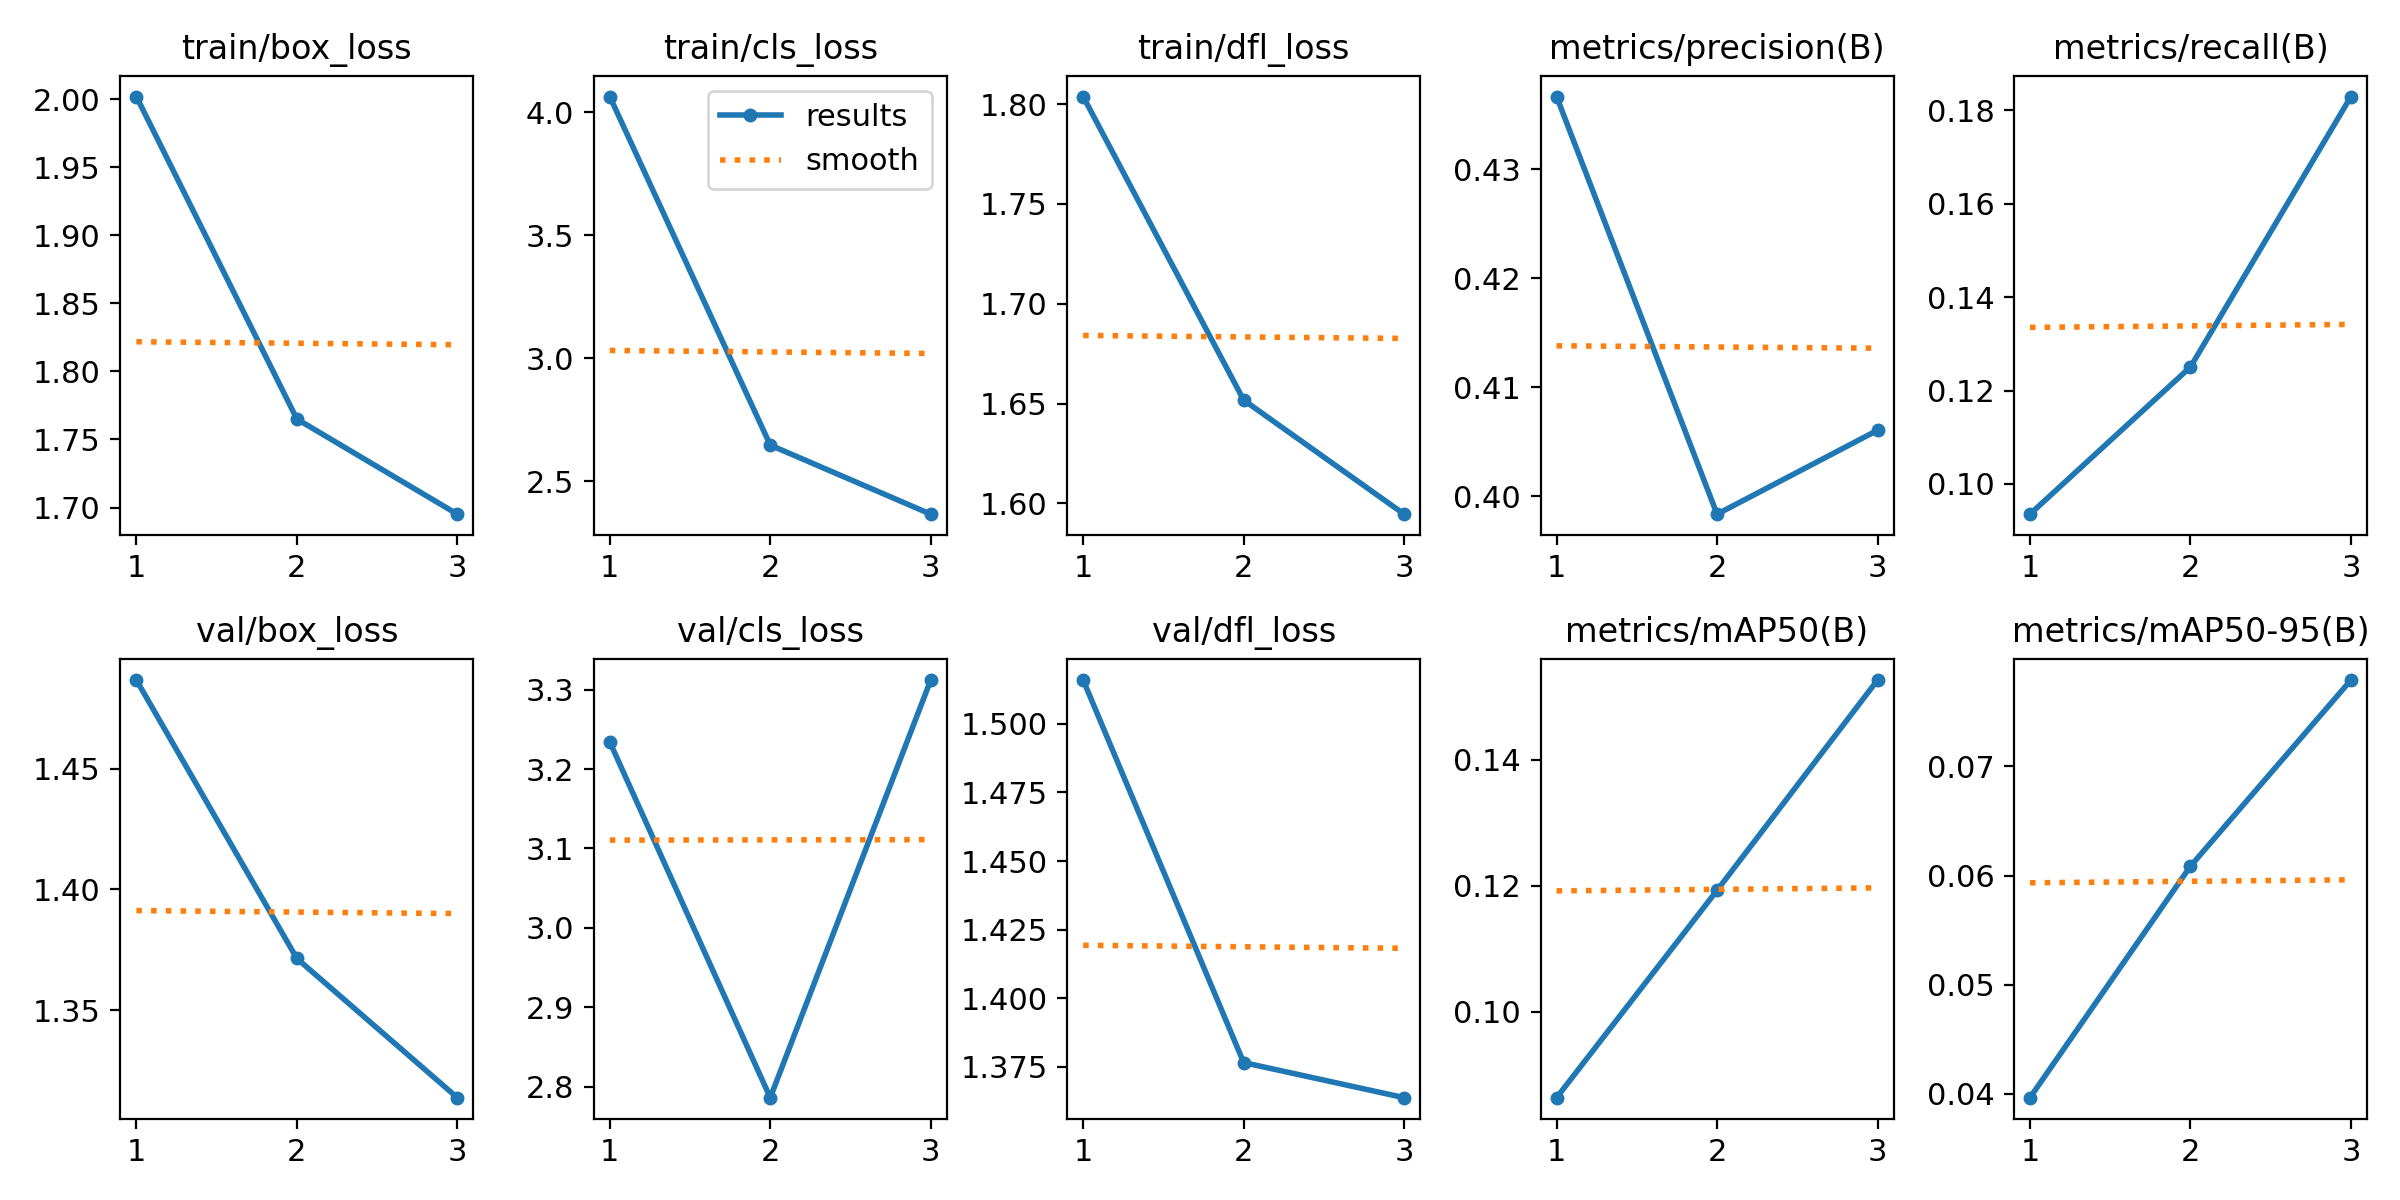


--- YOLOv8 Baseline Validation Predictions ---


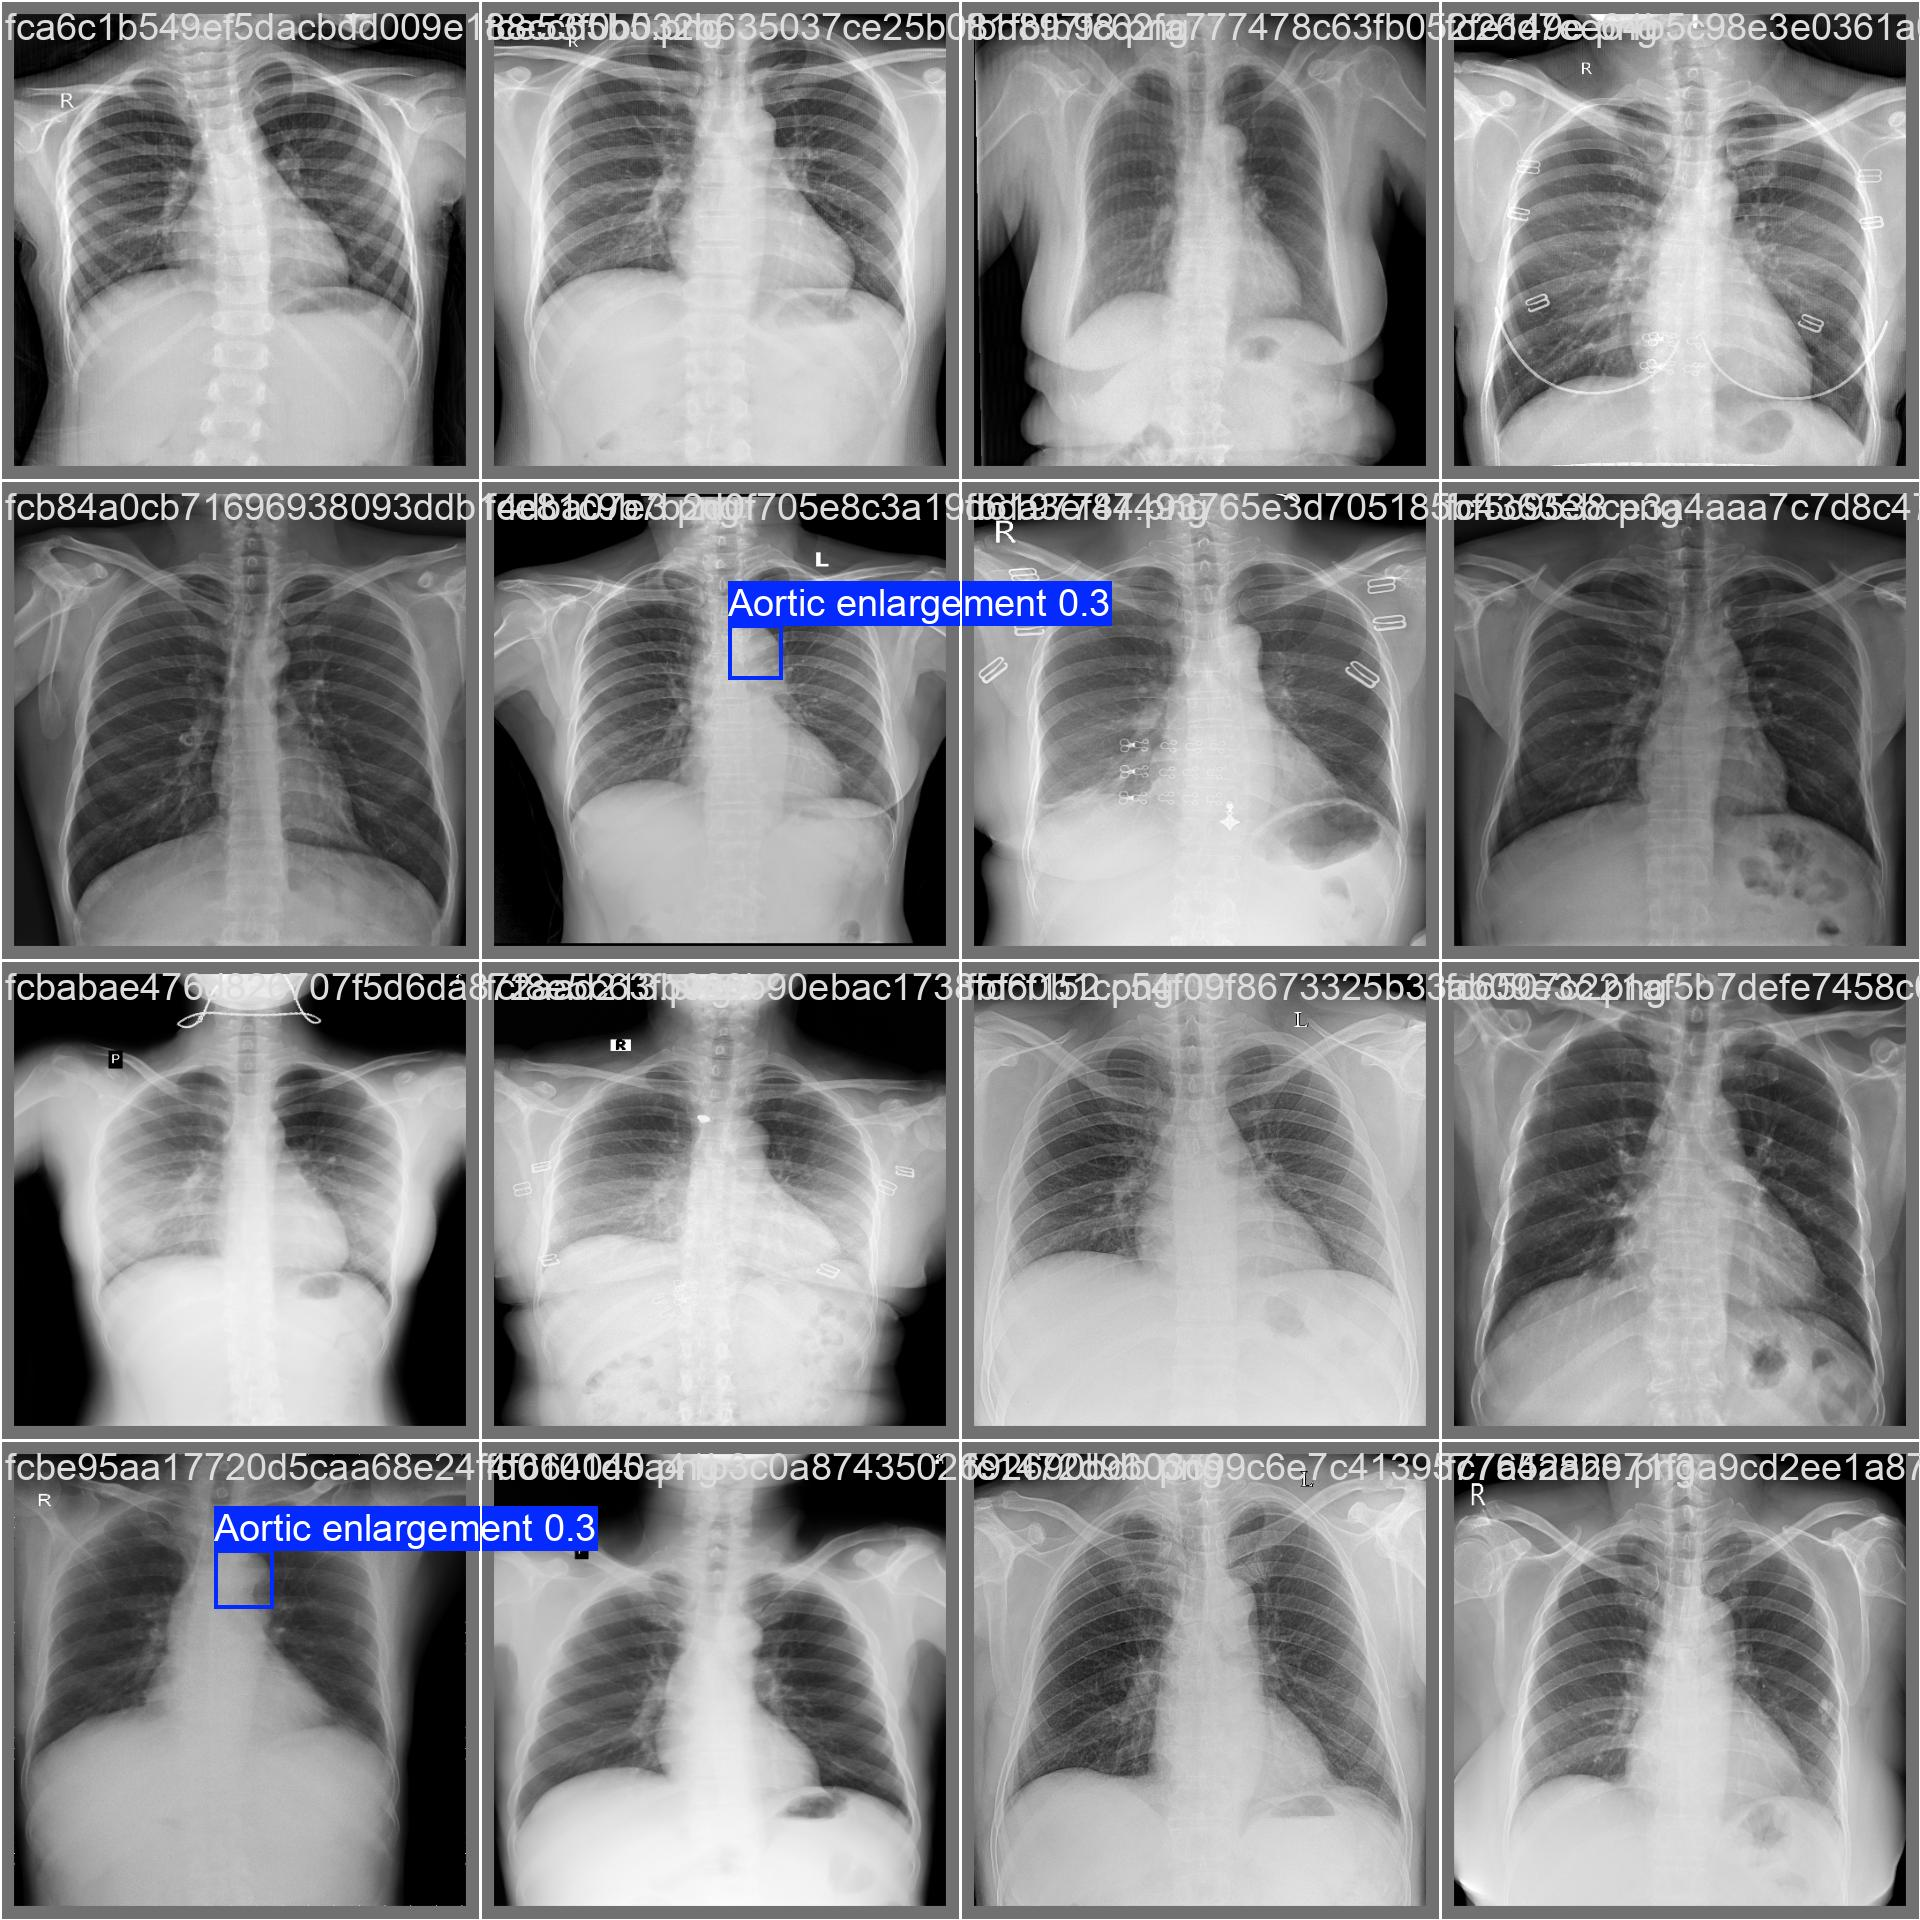

In [8]:
from IPython.display import Image, display

results_path = os.path.join(OUTPUT_DIR, "yolo_baseline", "results.png")
if os.path.exists(results_path):
    print("\n--- YOLOv8 Baseline Metrics Chart ---")
    display(Image(filename=results_path, width=800))

val_preds = glob.glob(os.path.join(OUTPUT_DIR, "yolo_baseline", "val_batch*_pred.jpg"))
if val_preds:
    print("\n--- YOLOv8 Baseline Validation Predictions ---")
    display(Image(filename=val_preds[0], width=800))
